
# A regression problem model using `randomForestRegressor`

#### Importing libraries

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# # loading the dataset from sklearn
# housing = fetch_california_housing(as_frame= True)
# df_housing = housing.frame # This converts to dataframe

# df_housing.head()

In [ ]:
df_housing = (
    
    fetch_california_housing(as_frame= True)
.frame # This converts to dataframe
#.info()
#.head()
#.isnull()
#.sum()
#.describe().T
)

- The data is cleaned so we move to:
#### Feature engineering

In [ ]:
#the target variable is MedHouseVal
X = df_housing.drop(columns=['MedHouseVal'])
y = df_housing['MedHouseVal']

#view the X, and y

print('The features are: \n', X.head())
print('\n\n')
print('The target vaariable is:\n', y.head())
print('\n\n')
print('The column name of X features are:', X.columns.values)

The features are: 
    MedInc  HouseAge  AveRooms  ...  AveOccup  Latitude  Longitude
0    8.33     41.00      6.98  ...      2.56     37.88    -122.23
1    8.30     21.00      6.24  ...      2.11     37.86    -122.22
2    7.26     52.00      8.29  ...      2.80     37.85    -122.24
3    5.64     52.00      5.82  ...      2.55     37.85    -122.25
4    3.85     52.00      6.28  ...      2.18     37.85    -122.25

[5 rows x 8 columns]



The target vaariable is:
 0   4.53
1   3.58
2   3.52
3   3.41
4   3.42
Name: MedHouseVal, dtype: float64



The column name of X features are: <ArrowStringArray>
[    'MedInc',   'HouseAge',   'AveRooms',  'AveBedrms', 'Population',
   'AveOccup',   'Latitude',  'Longitude']
Length: 8, dtype: str


# splitting dataset into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=234)

#confirming the shape of each splits
print(f'    X_train: {X_train.shape}\n\
    X_test: {X_test.shape}\n\
    y_train: {y_train.shape}\n\
    y_test: {y_test.shape}\
    ')


    X_train: (16512, 8)
    X_test: (4128, 8)
    y_train: (16512,)
    y_test: (4128,)    


#### Training the algorithm

In [ ]:
model = RandomForestRegressor (n_estimators=100,random_state=234)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",234
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease 

## Prediction

In [ ]:
y_pred = model.predict(X_test)

#display prediction vs actual

y_pred

array([2.22447  , 4.6459159, 3.3150804, ..., 1.46865  , 1.91831  ,
       1.3035   ], shape=(4128,))

#### Visualisation of the actual vs predicted

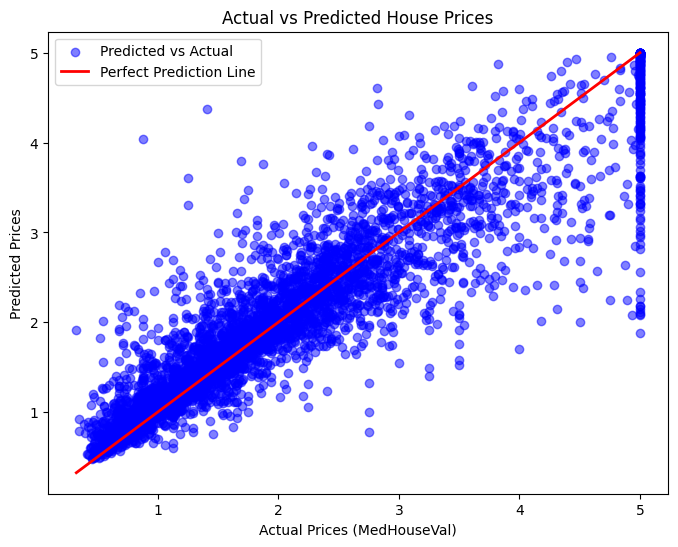

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r", lw=2, label="Perfect Prediction Line")
plt.xlabel("Actual Prices (MedHouseVal)")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

#### How important are the features in splitting the trees across the dataset

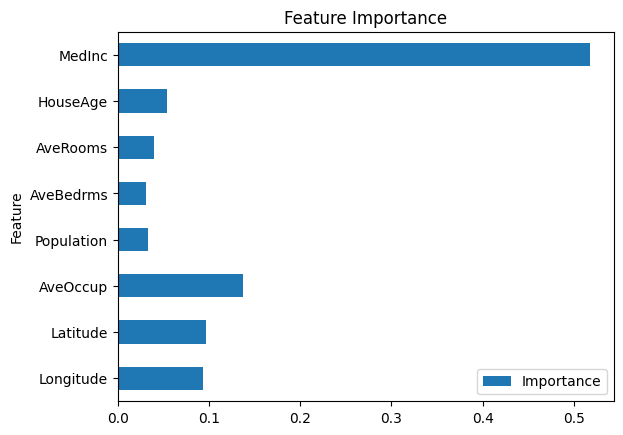

In [ ]:

feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

#print(feat_imp_df)

feat_imp_df.plot(kind='barh', x='Feature', y='Importance')
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()


#### Compare the outcomes of pred vs actual

In [ ]:

df_result = pd.DataFrame(
    {'Actual_y': y_test,
     'Predicted_y': y_pred
     }
)
df_result.head()

,Actual_y,Predicted_y
10851,1.61,2.22
5486,5.00,4.65
8813,3.96,3.32
4600,1.18,1.87
13854,0.93,1.19


In [ ]:
# Difference between actual and predicted
diff = df_result['Actual_y'] - df_result['Predicted_y']
df_result['Residual'] = diff
df_result['|Residual|'] = abs(diff)
df_result.head()

,Actual_y,Predicted_y,Residual,|Residual|
10851,1.61,2.22,-0.61,0.61
5486,5.00,4.65,0.35,0.35
8813,3.96,3.32,0.65,0.65
4600,1.18,1.87,-0.69,0.69
13854,0.93,1.19,-0.26,0.26


## Evaluate model

In [ ]:
# See the max and min of the actual and predicted value
print('=' * 80)
print('             Min and Max value of the actual and predicted value')
print('=' * 80)
print('')
print(f'Min_actual_y: {df_result['Actual_y'].min():.2f}')
print(f'Max_actual_y: {df_result['Actual_y'].max():.2f}')
print(f'Min_pred_y: {df_result['Predicted_y'].min():.2f}')
print(f'Max_pred_y: {df_result['Predicted_y'].max():.2f}')

             Min and Max value of the actual and predicted value

Min_actual_y: 0.33
Max_actual_y: 5.00
Min_pred_y: 0.48
Max_pred_y: 5.00


In [ ]:
# Calculate mean absolute error
MAE = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {MAE:.3f}')

# Calculate mean square error
MSE = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {MSE:.3f}')

#calculate the RMSE manually
RMSE = np.sqrt(MSE)
print(f'Root mean squared error: {RMSE:.3f}')

Mean Absolute Error: 0.320
Mean Squared Error: 0.243
Root mean squared error: 0.493


- To make RMSE more interpretable with reference to the median house value, we need to convert predicted to the currency of the target variable (dollar).
- we convert the predicted_y to dollar ( * 1000)
- add and subtract the RMSE to get the highest and lowest price range
- Then have them side by side with the actual median value

In [ ]:
df_result['Actual_y'] = df_result['Actual_y'] * 100000 #convert to dollar
df_result['Predicted_y'] = df_result['Predicted_y'] * 100000
#calc rmse in dollar
rmse_dol = np.sqrt(mean_squared_error(df_result['Actual_y'], df_result['Predicted_y']))
#calc max and min price range
df_result['Max_Price_Range'] = df_result['Predicted_y'] + rmse_dol
df_result['Min_Price_Range'] = df_result['Predicted_y'] - rmse_dol

#compare the actual, predicted and min, max range
pd.options.display.float_format = '{:.2f}'.format
df_result[['Predicted_y', 'Max_Price_Range', 'Min_Price_Range', 'Actual_y']].head()


,Predicted_y,Max_Price_Range,Min_Price_Range,Actual_y
10851,222447.00,271725.36,173168.64,161000.00
5486,464591.59,513869.95,415313.23,500001.00
8813,331508.04,380786.40,282229.68,396400.00
4600,186893.00,236171.36,137614.64,118100.00
13854,119436.01,168714.37,70157.65,93400.00


In [ ]:
# assign another column to know which price is in range
df_result['Actual_in_Pred_Range'] = np.where(
    (df_result['Actual_y'] >= df_result['Min_Price_Range']) &
    (df_result['Actual_y'] <= df_result['Max_Price_Range']),
    'Yes',
    'No'
)
    
df_result.head(10)


,Actual_y,Predicted_y,Residual,|Residual|,Max_Price_Range,Min_Price_Range,Actual_in_Pred_Range
10851,161000.00,222447.00,-0.61,0.61,271725.36,173168.64,No
5486,500001.00,464591.59,0.35,0.35,513869.95,415313.23,Yes
8813,396400.00,331508.04,0.65,0.65,380786.40,282229.68,No
4600,118100.00,186893.00,-0.69,0.69,236171.36,137614.64,No
13854,93400.00,119436.01,-0.26,0.26,168714.37,70157.65,Yes
339,80700.00,174737.00,-0.94,0.94,224015.36,125458.64,No
6944,160700.00,163861.00,-0.03,0.03,213139.36,114582.64,Yes
8322,100800.00,103413.00,-0.03,0.03,152691.36,54134.64,Yes
15108,166100.00,162902.00,0.03,0.03,212180.36,113623.64,Yes
14660,179100.00,180457.00,-0.01,0.01,229735.36,131178.64,Yes


In [ ]:
# Check how many actual falls within the predicted range

print(f'Avg. Coverage: {(df_result['Actual_in_Pred_Range'] == 'Yes').mean() * 100:.2f}%')

# how many were captured
print(f'The model captured {(df_result['Actual_in_Pred_Range'] == 'Yes').sum()}\
 out of {len(y_test)} predictions\
      ')

Avg. Coverage: 80.16%
The model captured 3309 out of 4128 predictions      


##### Calculating MAE in dollars and R2

In [ ]:
mae_dol = mean_absolute_error(df_result['Actual_y'], df_result['Predicted_y'])

print(round(mae_dol, 2),'dollars')

31998.99 dollars


In [ ]:
# R2
r2 = r2_score(df_result['Actual_y'], df_result['Predicted_y'])

print ('R-squared:', round(r2, 2),'%')

R-squared: 0.82 %


### Saving model



In [ ]:
import joblib
#model_filename = 'trained_iris_model.pkl'

# save the best model
joblib.dump(model, 'trained_california_model.pkl')
print(f'Model saved as trained_california_model.pkl')


Model saved as trained_california_model.pkl


In [ ]:
# Retrieveing the model
model_filename = 'trained_california_model.pkl'

loaded_model = joblib.load(model_filename)
print("\nModel loaded successfully!")

# Verify it works by making a test prediction
test_prediction = loaded_model.predict((X_test[:5])) #scales the X_test and print out first 5
print("\nTest predictions with loaded model:")
print(test_prediction)

print("\nActual values:")
print(y_test[:5].values) 


Model loaded successfully!

Test predictions with loaded model:
[2.22447   4.6459159 3.3150804 1.86893   1.1943601]

Actual values:
[1.61    5.00001 3.964   1.181   0.934  ]


### Retrieving model and test

In [ ]:
# convert the test prediction dollar
d = pd.DataFrame({
    
    'Actual':y_test[:5] * 100000,
    'Predicted':test_prediction * 100000
})

d



,Actual,Predicted
10851,161000.00,222447.00
5486,500001.00,464591.59
8813,396400.00,331508.04
4600,118100.00,186893.00
13854,93400.00,119436.01
